### Lab 2

Step 1 - Create Dummy Dataset

In [8]:
	import numpy as np
	from sklearn.datasets import make_classification
	
	# Create dummy data
	# The output of make_classification consists of feature data X and labels y
	# The labels y will be encoded (numerical) data
	X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False, random_state=42)
	
	# By default, make_classification produces float values
	# We need to convert them to discrete form
	
	# Take the absolute value of the values
	X = np.absolute(X)
	
	# Round values to two decimal places
	# Multiply by 100 so that there are no decimal points
	X = np.round(X, 2) * 100
	
	# Convert to integer type
	X = X.astype(int)
	
	# Check the result
	print(X)
	print(y)

[[112 139]
 [179 210]
 [ 83  71]
 [182 265]
 [105  78]
 [ 67  43]
 [ 36  54]
 [ 20  70]
 [122  70]
 [250  83]
 [ 50 142]
 [206 110]
 [115  84]
 [124  66]
 [150  85]
 [ 16  73]
 [ 46 113]
 [ 26  80]
 [ 18 114]
 [211 154]
 [ 53  66]
 [ 93 109]
 [175 172]
 [ 80  85]
 [111 125]
 [115 105]
 [ 66  92]
 [160  85]
 [ 53 106]
 [122  85]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


Step 2 (Optional) - Create DataFrame

In [9]:
import pandas as pd

# Reshape label y into 2D
# This is done because we will concatenate it with the feature data X
y_new = y.reshape(len(y), 1)

# Concatenate features X and label y into an array
data = np.concatenate((X, y_new), axis=1)

# Define column names
nama_kolom = ['Feature 1', 'Feature 2', 'Label']

# Create DataFrame
df = pd.DataFrame(data, columns=nama_kolom)

# Inspect the DataFrame
df.head()

,Feature 1,Feature 2,Label
0,112,139,0
1,179,210,0
2,83,71,0
3,182,265,0
4,105,78,0


Step 3 (Optional) - Labeling

In [10]:
	# Define label names
	labels = {
	    1 : 'Class A',
	    0 : 'Class B'
	}
	
	# Copy the DataFrame to create a new DataFrame
	# with more readable labels
	df_label = df.copy()
	
	# Replace labels using the Pandas mapping function
	# on the df_label DataFrame
	df_label['Label'] = df_label['Label'].map(labels)
	
	# Inspect the df_label DataFrame
	df_label.head()

	display(df_label)

,Feature 1,Feature 2,Label
0,112,139,Class B
1,179,210,Class B
2,83,71,Class B
3,182,265,Class B
4,105,78,Class B
5,67,43,Class B
6,36,54,Class B
7,20,70,Class B
8,122,70,Class A
9,250,83,Class A


Step 4 - Data Visualization

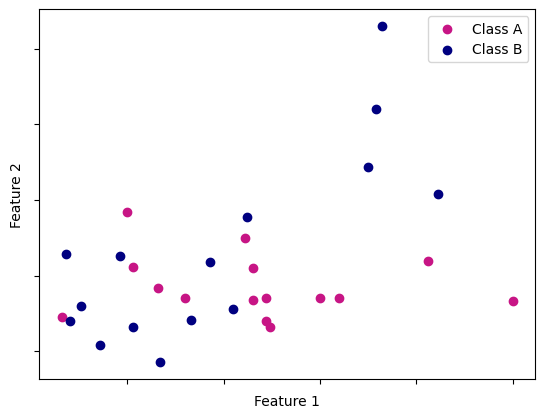

In [11]:
	import matplotlib.pyplot as plt
	
	# Define colors for each class
	colors = {
	    'class_a': 'MediumVioletRed',
	    'class_b': 'Navy'
	}
	
	# Select each class without requiring both groups to exist
class_a = df_label[df_label['Label'] == 'Class A']
class_b = df_label[df_label['Label'] == 'Class B']
	
	# Plot
	plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['class_a'])
	plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['class_b'])
	plt.xlabel('Feature 1')
	plt.ylabel('Feature 2')
	plt.legend(['Class A', 'Class B'])
	plt.gca().axes.xaxis.set_ticklabels([])
	plt.gca().axes.yaxis.set_ticklabels([])
	plt.show()

Step 5 - Multinomial Naive Bayes Model

In [12]:
	from sklearn.naive_bayes import MultinomialNB # class for the MultinomialNB model
	from sklearn.model_selection import train_test_split
	from sklearn.metrics import accuracy_score # evaluate the model using accuracy
	
	# Instantiate a MultinomialNB object
	mnb = MultinomialNB()
	
	# We can directly use the feature matrix X and labels y
	# resulting from the dummy data generation process
	
	# Split training and testing data
	X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)
	
	# Fit the model
	# The label y must be in 1D form or (n_samples,)
	mnb.fit(X_train, y_train)
	
	# Predict on training data
	y_train_pred = mnb.predict(X_train)
	
	# Evaluate training accuracy
	acc_train = accuracy_score(y_train, y_train_pred)
	
	# Predict test data
	y_test_pred = mnb.predict(X_test)
	
	# Evaluate the model using the accuracy metric
	acc_test = accuracy_score(y_test, y_test_pred)
	
	# Print evaluation results
	print(f'Training accuracy: {acc_train}')
	print(f'Test accuracy: {acc_test}')

Training accuracy: 0.8095238095238095
Test accuracy: 0.3333333333333333


Step 6 - Gaussian Naive Bayes Model

In [13]:
from sklearn.naive_bayes import GaussianNB # class for the GaussianNB model

# Instantiate a Gaussian object
gnb = GaussianNB()

# We use the same training and testing split
# as used for the multinomial model

# Fit the model
# The label y must be in 1D form or (n_samples,)
gnb.fit(X_train, y_train)

# Predict on training data
y_train_pred_gnb = gnb.predict(X_train)

# Evaluate training accuracy
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

# Predict test data
y_test_pred_gnb = gnb.predict(X_test)

# Evaluate the model using the accuracy metric
acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

# Print evaluation results
print(f'Training accuracy (Gaussian): {acc_train_gnb}')
print(f'Test accuracy (Gaussian): {acc_test_gnb}')

Training accuracy (Gaussian): 0.8571428571428571
Test accuracy (Gaussian): 0.4444444444444444
